<a href="https://colab.research.google.com/github/Apekshya175/AI-ML/blob/main/Worksheet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3.2 Task-1: Implementation of MCP Neurons:


1.Design a MCP Neuron for ”AND” Boolean Functions and ”OR”Boolean Functions with two
inputs:
Hint:
•Aggregate all the inputs.
•Handcraft a Threshold values for ”AND” and ”OR” Function.
•Implement a if else statement as stated above.

AND OPERATION

In [ ]:
def MCP_Neurons_AND (X1, X2,T):
  assert len(X1)== len(X2)
  output_neuron =[]
  for i in range(len(X1)):
    z = X1[i] + X2[i]
    if z>=T:
      output_neuron.append(1)
    else:
      output_neuron.append(0)
  return output_neuron


In [ ]:
X1 = [0,0,1,1]
X2 = [0,1,0,1]
T = 2
result = MCP_Neurons_AND(X1,X2,T)
print(f"Output of AND gate for inputs{X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs[0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


OR OPERATION

In [ ]:
def MCP_Neurons_OR(X1,X2,T):
  assert len(X1)== len(X2)

  output_neuron = []
  for i in range(len(X1)):
     z = X1[i]+X2[i]
     if z>=T:
       output_neuron.append(1)
     else:
       output_neuron.append(0)
  return output_neuron

In [ ]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1
result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


3.2.1 Answer the Following Question:

Question1:
List out all limitations of MCP - Neurons

Answer:


*   Has a single-layer structure (no hidden layers)


*   Can only solve linearly separable problems

*   Cannot handle non-linearly separable problems like XOR
*   Learning mechanism is absent since weights and threshold are fixed


*   Model works only on binary inputs and outputs and cannot model complex patterns




Question2:
Think if you can develop a logic to solve for XOR function using MCP Neuron.


Answer:

XOR can be implemented using if-else rules where output is 1 when inputs differ and 0 when they are the same, although a single MCP neuron cannot solve it directly.









    


In [ ]:
def MCP_Neurons_XOR(X1,X2):
  output_neuron=[]
  for i in range(len(X1)):
    if (X1[i] == 0 and X2[i] ==1) or (X1[i] ==1 and X2[i]==0):
      output_neuron.append(1)
    else:
      output_neuron.append(0)
  return output_neuron



In [ ]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
result_xor = MCP_Neurons_XOR(X1, X2)
print(f"Output of XOR gate for inputs {X1} and {X2}: {result_xor}")

Output of XOR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1]: [0, 1, 1, 0]


4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification.


2. Load the Dataset:


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_0_and_1.csv")
df

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12660,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12661,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12662,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12663,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = df.drop(columns =['label']).values
y = df['label'].values
print("Feature matrix shape:", X.shape)
print("Feature vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Feature vector shape: (12665,)


Answer the Following Question:

1. Question- 1: What does the shape of X represent?

Answer:

Shape of X represent is 2D.X has shape (n_smaples, 784) representing the number of images and 784 pixel features each.



2. Question- 2: What does the shape of X represent?

Answer:

Shape of Y represent is 1D.Y has shape (n_smaples,) holding class labels

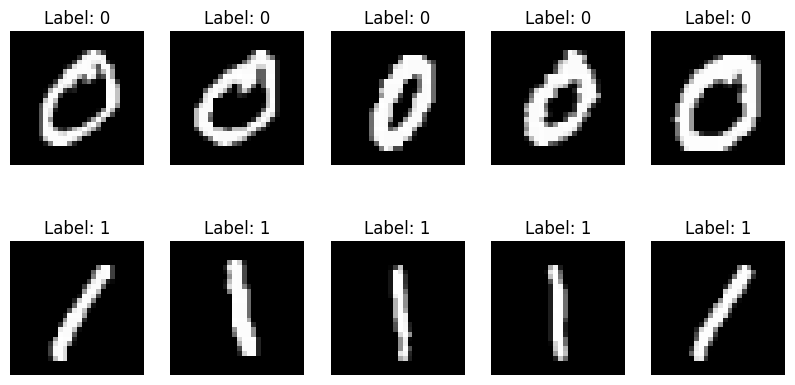

In [ ]:
import matplotlib.pyplot as plt
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.show()

3. Initialize Weights and Bias:


In [ ]:

weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

Answer the Following Question:
1. Question- 3: What does the weights array represent in this context?

Answer: The weight array represents importance of each input feature in making prediction. Weights say how strongly each feature affects the output.(X.weights)

2. Question- 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

Answer:We initialize the weights to zero because the model has not learned anything yet, so it provides a neutral starting point. For a perceptron, this does not cause problems because weights are updated differently for each training example. Therefore, the model can still learn effectively.

4. Implement a Decision Function or Activation Function:


In [ ]:
def decision_function(X,weights, bias):

   predictions = np.dot(X,weights) + bias
   y_pred_all = np.where(predictions>=0 ,1,0)
   return y_pred_all


5. Implement the Perceptron Learning Algorithm:


In [ ]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        for i in range(X.shape[0]):
            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0
            error = y[i] - y_pred

            weights += learning_rate * error * X[i]
            bias += learning_rate * error

    final_pred = decision_function(X, weights, bias)
    accuracy = np.mean(final_pred == y)

    return weights, bias, accuracy

weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias)
print("The training Accuracy is:", accuracy)

The training Accuracy is: 1.0


AnswertheFollowingQuestion:


1. Question- 5: What is the purpose of the output=np.dot(X[i],weights)+ biasline?

Answer: The line output = np.dot(X[i], weights) + bias is used to find the total input for a training example by multiplying each feature with its weight and adding the bias. This tells the perceptron what the raw prediction should be.





2. Question- 6: What happens when the prediction is wrong? How are the weights and bias updated?

Answer: If the prediction is wrong, the perceptron changes the weights and bias to fix the mistake. It adds a small amount based on the error and the input features to the weights, and also changes the bias by the error. This helps the model learn and get better.





3. Question- 7: Why is the final accuracy important, and what do you expect it to be?

Answer: The final accuracy is important because it shows how many examples the perceptron got right. If the data can be separated by a line, the accuracy should reach 100%. If not, it will be less, but it still tells us how well the model learned.

In [ ]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Answer the Following Question:
1. Question- 8:What does misclassified idx store, and how is it used in this code?

Answer: misclassified_idx stores the indices of the training examples that the model predicted incorrectly. In the code, it is used to find and display the first 10 images that were misclassified, showing the predicted label and the true label. This helps us see exactly where the model made mistakes.

2. Question- 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

Answer: If the output is “All images were correctly classified!”, it means that the perceptron predicted every example in the dataset correctly. There are no mistakes, so the model has learned the data perfectly, and the final accuracy is 100%.

4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.


1. Load Dataset :

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_3_and_5.csv")
df

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2736,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2737,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2738,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2739,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X = df.drop(columns=['label']).values / 255.0
y_original = df['label'].values
y = np.where(y_original == 3, 0, 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


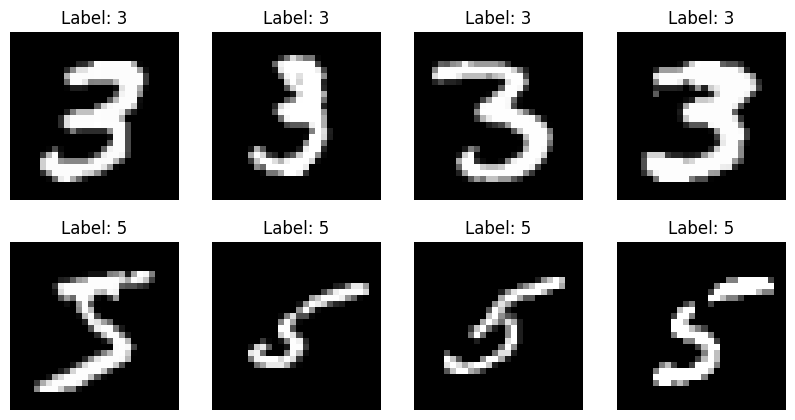

In [ ]:
import matplotlib.pyplot as plt

image_3 = X[y_original == 3]
image_5 = X[y_original == 5]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

if len(image_3) < 5 or len(image_5) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(4):
        # Row 1 → label 3
        axes[0, i].imshow(image_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        # Row 2 → label 5
        axes[1, i].imshow(image_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.show()

3. Initialize Weights and Bias:


In [ ]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100



4. Implementation of decison fucntion

In [ ]:

def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

5.Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        for i in range(X.shape[0]):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0
            error = y[i] - y_pred

            weights += learning_rate * error * X[i]
            bias += learning_rate * error

    final_pred = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.mean(final_pred == y)

    return weights, bias, accuracy

# Train
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print("The training Accuracy is:", accuracy)

# Predictions
y_pred = decision_function(X, weights, bias)

# Final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")



The training Accuracy is: 0.9916089018606348
Final Accuracy: 0.9916


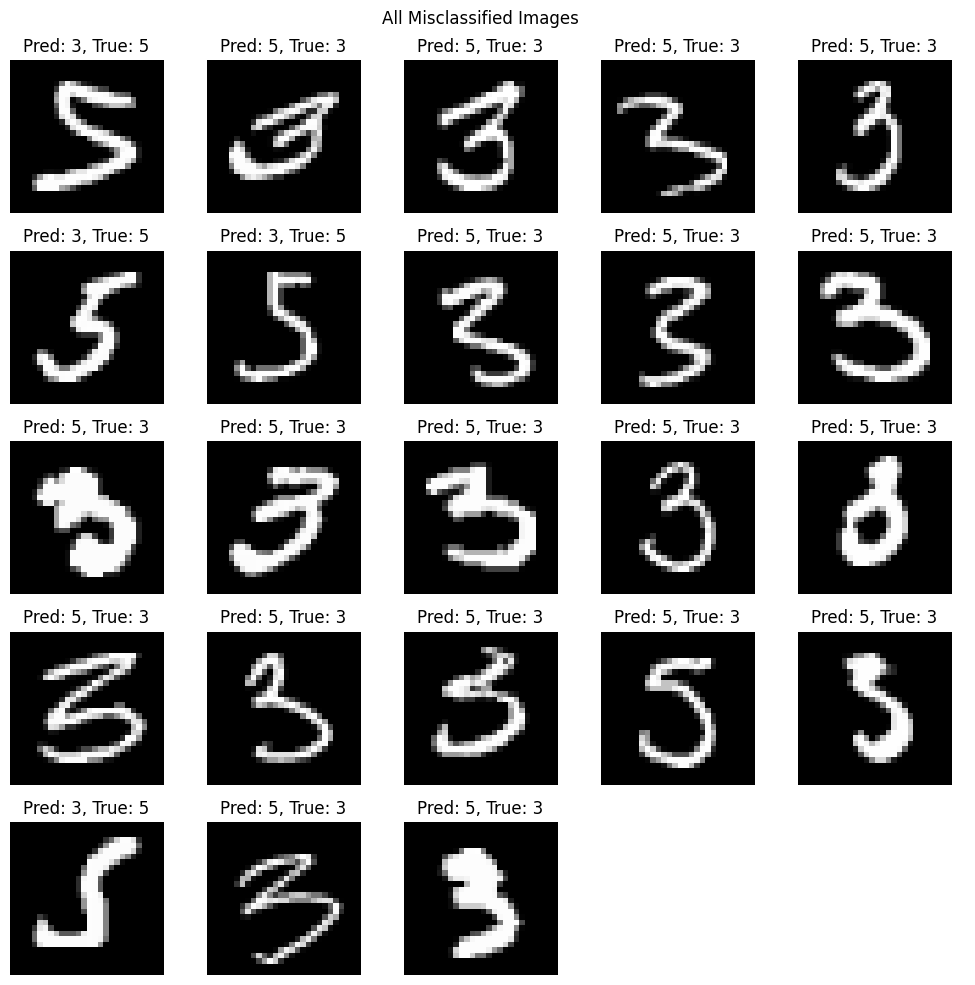

In [ ]:
import math

misclassified_idx = np.where(y_pred != y)[0]
label_map = {0: 3, 1: 5}

n = len(misclassified_idx)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 2*rows))

for ax, idx in zip(axes.flat, misclassified_idx):
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred: {label_map[y_pred[idx]]}, True: {y_original[idx]}")
    ax.axis("off")

for ax in axes.flat[n:]:
    ax.axis("off")

plt.suptitle("All Misclassified Images")
plt.tight_layout()
plt.show()

Conclusion:
In this task, I implemented the Perceptron algorithm to classify digits 3 and 5 from the MNIST dataset. After training for 100 epochs, the model was able to correctly classify most of the images. However, looking at the misclassified images, I can see that some 3s and 5s look very similar in shape, which makes it harder for the perceptron to separate them correctly compared to 0 vs 1 classification.
This shows the limitation of the perceptron it can only draw a straight line (linear decision boundary) to separate two classes. Since 3 and 5 share similar curves and strokes, some examples fall on the wrong side of that boundary and get misclassified. To improve this, we would need a more complex model like a multi-layer neural network that can learn non-linear patterns.
